# LOB Data Efficiency: DeepLOB and LOB-Transformer

**Goal:** Empirically measure how much real labeled data each model needs to reach competent performance on mid-price movement prediction, using the FI-2010 benchmark dataset (Setup 2: 7-day train, 3-day test).

We sweep training data fractions `[1%, 2%, 5%, 10%, 20%, 50%, 100%]` and record weighted F1 at each fraction for:
- **DeepLOB** — the Conv+Inception+LSTM architecture from Zhang et al. (2019)
- **LOBTransformer** — a lightweight transformer with LOB-aware input projection

The resulting data efficiency curves directly motivate synthetic data augmentation: if both models plateau or degrade sharply with less data, synthetic pre-training or augmentation becomes valuable.

---
**Dataset:** [FI-2010](https://etsin.fairdata.fi/dataset/73eb48d7-4dbc-4a10-a52a-da745b47a649) — 10 days, 5 NASDAQ Nordic stocks, horizon k ∈ {10, 20, 50}  

## 0. Setup & Imports

In [1]:
import os
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from sklearn.metrics import f1_score, classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

# ── Reproducibility ─────────────────────────────────────────────────────────
GLOBAL_SEED = 42

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(GLOBAL_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## 1. FI-2010 Data Loading

**Download instructions:** Request the dataset at https://etsin.fairdata.fi/dataset/73eb48d7-4dbc-4a10-a52a-da745b47a649  
After downloading, unzip to a directory and set `DATA_ROOT` below. The directory should contain `BenchmarkDatasets/` with the `NoAuction` subdirectory.

In [2]:
from google.colab import drive
drive.mount('/content/drive/')
!mkdir -p /content/data
!unzip -q -o /content/drive/MyDrive/colab_data/FI-2010.zip -d /content/data/
!unzip -q -o /content/data/published/BenchmarkDatasets/BenchmarkDatasets.zip -d /content/data/

Mounted at /content/drive/


In [3]:
# ── Configuration ────────────────────────────────────────────────────────────
DATA_ROOT   = Path('/content/data')
RESULTS_DIR = Path('./results')
RESULTS_DIR.mkdir(exist_ok=True)

# Experiment hyperparameters
T           = 100          # LOB lookback window (100 events, same as DeepLOB paper)
HORIZONS    = [10, 20, 50] # prediction horizons k
FRACTIONS   = [0.01, 0.05, 0.10, 0.20, 0.50, 1.00]  # training data fractions
N_SEEDS     = 3            # seeds per fraction (for error bars)
MAX_EPOCHS  = 50           # cap for speed; paper uses ~100 on full data
PATIENCE    = 7           # early stopping patience
BATCH_SIZE  = 512
LR          = 1e-3

In [4]:
def load_fi2010_setup2(
    data_root: Path,
    auction: str = 'NoAuction',
    normalisation: str = 'Zscore',
    horizon_idx: int = 0,
    n_train_files: int = 7,
):
    """
    Load FI-2010 in Setup 2.
    """
    norm_map = {
        'Auction': {
            'Zscore': ('1.Auction_Zscore',   'Auction_Zscore',   'ZScore'),
            'MinMax': ('2.Auction_MinMax',    'Auction_MinMax',   'MinMax'),
            'DecPre': ('3.Auction_DecPre',    'Auction_DecPre',   'DecPre'),
        },
        'NoAuction': {
            'Zscore': ('1.NoAuction_Zscore',  'NoAuction_Zscore', 'ZScore'),
            'MinMax': ('2.NoAuction_MinMax',  'NoAuction_MinMax', 'MinMax'),
            'DecPre': ('3.NoAuction_DecPre',  'NoAuction_DecPre', 'DecPre'),
        },
    }

    folder_num, split_prefix, fname_norm = norm_map[auction][normalisation]

    # Point directly to extracted BenchmarkDatasets folder
    base = data_root / 'BenchmarkDatasets' / auction / folder_num

    train_dir = base / f'{split_prefix}_Training'
    test_dir  = base / f'{split_prefix}_Testing'

    def _load_files(directory: Path, prefix: str, indices: list) -> tuple:
        Xs, ys = [], []
        for i in indices:
            fname = directory / f'{prefix}_Dst_{auction}_{fname_norm}_CF_{i}.txt'
            if not fname.exists():
                raise FileNotFoundError(f'Expected file not found: {fname}')
            arr = np.loadtxt(fname)
            X = arr[:-5, :].T.astype(np.float32)
            y = arr[-(5 - horizon_idx), :].astype(int) - 1
            Xs.append(X)
            ys.append(y)
        return np.concatenate(Xs, axis=0), np.concatenate(ys, axis=0)

    train_indices = list(range(1, n_train_files + 1))
    test_indices  = list(range(n_train_files + 1, 10))

    X_train, y_train = _load_files(train_dir, 'Train', train_indices)
    X_test,  y_test  = _load_files(test_dir,  'Test',  test_indices)

    return X_train, y_train, X_test, y_test

# Reload the data mapping
fi2010 = {}
for h_idx, k_label in zip([0, 1, 3], [10, 20, 50]):
    X_tr, y_tr, X_te, y_te = load_fi2010_setup2(
        DATA_ROOT,
        auction='NoAuction',
        normalisation='Zscore',
        horizon_idx=h_idx,
    )
    fi2010[k_label] = (X_tr, y_tr, X_te, y_te)
    print(f'Loaded k={k_label}: Train={X_tr.shape}, Test={X_te.shape}')

Loaded k=10: Train=(1017738, 144), Test=(84109, 144)
Loaded k=20: Train=(1017738, 144), Test=(84109, 144)
Loaded k=50: Train=(1017738, 144), Test=(84109, 144)


## 2. Dataset & DataLoader

We follow DeepLOB exactly: each sample is a sliding window of `T=100` consecutive LOB states → `(T, 40)` input tensor.

In [5]:
class LOBDataset(Dataset):
    """
    Sliding-window LOB dataset.

    Each sample: X[i : i+T] → shape (T, 40), label y[i+T-1]
    """
    def __init__(self, X: np.ndarray, y: np.ndarray, T: int = 100):
        super().__init__()
        assert len(X) == len(y), 'X and y must have the same number of rows'
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.T = T

    def __len__(self):
        return len(self.X) - self.T + 1

    def __getitem__(self, idx):
        x_window = self.X[idx : idx + self.T]   # (T, 40)
        label    = self.y[idx + self.T - 1]     # scalar
        return x_window, label


def make_loaders(
    X_train, y_train, X_test, y_test,
    fraction: float = 1.0,
    T: int = 100,
    batch_size: int = 64,
    seed: int = 42,
):
    """Build train/test DataLoaders, sub-sampling train to `fraction`."""
    train_full = LOBDataset(X_train, y_train, T)
    test_ds    = LOBDataset(X_test,  y_test,  T)

    # Contiguous head slice to avoid data leakage (time-series order preserved)
    n_subset = max(1, int(len(train_full) * fraction))
    train_ds = Subset(train_full, list(range(n_subset)))

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=2, pin_memory=(DEVICE.type == 'cuda')
    )
    test_loader = DataLoader(
        test_ds, batch_size=512, shuffle=False,
        num_workers=2, pin_memory=(DEVICE.type == 'cuda')
    )
    return train_loader, test_loader, n_subset


# Quick sanity check
k = 10
X_tr, y_tr, X_te, y_te = fi2010[k]
train_ld, test_ld, _ = make_loaders(X_tr, y_tr, X_te, y_te, fraction=0.1)
xb, yb = next(iter(train_ld))
print(f'Batch shapes — X: {xb.shape}, y: {yb.shape}')
n_feats = fi2010[10][0].shape[1]
print(f'Feature dim: {n_feats}')

Batch shapes — X: torch.Size([64, 100, 144]), y: torch.Size([64])
Feature dim: 144


--- Sample of X_train (first 5 rows) ---


,0,1,2,3,4,5,6,7,8,9,...,134,135,136,137,138,139,140,141,142,143
0,0.408275,-0.509405,0.403577,-0.479331,0.409877,-0.663252,0.402914,-0.37744,0.409493,-0.787505,...,-1.597065,0.0,0.0,0.0,-0.143968,-0.879782,-0.887778,0.0,0.0,0.0
1,0.408275,-0.604272,0.403577,-0.479331,0.410898,-0.683978,0.402914,-0.37744,0.410513,-0.799630,...,-1.597065,0.0,0.0,0.0,-0.143968,0.381572,0.370280,0.0,0.0,0.0
2,0.407254,-0.663731,0.403577,-0.479331,0.406815,-0.663252,0.402914,-0.37744,0.407452,-0.695636,...,-1.597065,0.0,0.0,0.0,-0.143968,-0.862017,-0.870059,0.0,0.0,0.0
3,0.407254,-0.530115,0.403577,-0.479331,0.408857,-0.238357,0.402914,-0.37744,0.409493,-0.467596,...,0.626132,0.0,0.0,0.0,-0.143968,0.383221,0.371925,0.0,0.0,0.0
4,0.407254,-0.530115,0.403577,-0.479331,0.408857,-0.238357,0.402914,-0.37744,0.409493,-0.467596,...,0.626132,0.0,0.0,0.0,-0.143968,-0.479532,-0.488573,0.0,0.0,0.0



--- Distribution of y_train labels for k=10 ---


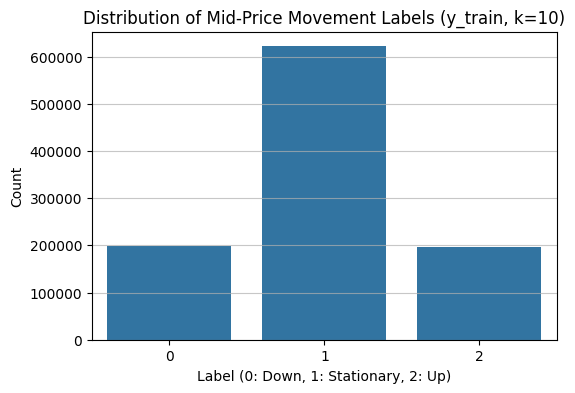

In [6]:
print('--- Sample of X_train (first 5 rows) ---')
# Displaying raw features for k=10
display(pd.DataFrame(fi2010[10][0][:5]))

print('\n--- Distribution of y_train labels for k=10 ---')
plt.figure(figsize=(6, 4))
sns.countplot(x=fi2010[10][1])
plt.title('Distribution of Mid-Price Movement Labels (y_train, k=10)')
plt.xlabel('Label (0: Down, 1: Stationary, 2: Up)')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.7)
plt.show()

## 3. Model Architectures

### 3.1 DeepLOB

Faithful re-implementation of the published architecture:  
`Conv(1×2 stride, ×2) → Conv(1×10) → Inception@32 → LSTM(64) → Softmax(3)`

In [ ]:
class InceptionModule(nn.Module):
    """Inception module as described in DeepLOB Figure 4."""

    def __init__(self, in_channels: int, n_filters: int = 32):
        super().__init__()
        # Branch 1: 1×1 → 3×1
        self.b1_1x1 = nn.Conv2d(in_channels, n_filters, kernel_size=(1, 1), padding='same')
        self.b1_3x1 = nn.Conv2d(n_filters,   n_filters, kernel_size=(3, 1), padding='same')

        # Branch 2: 1×1 → 5×1
        self.b2_1x1 = nn.Conv2d(in_channels, n_filters, kernel_size=(1, 1), padding='same')
        self.b2_5x1 = nn.Conv2d(n_filters,   n_filters, kernel_size=(5, 1), padding='same')

        # Branch 3: MaxPool(3×1) → 1×1
        self.b3_pool = nn.MaxPool2d(kernel_size=(3, 1), stride=1, padding=(1, 0))
        self.b3_1x1  = nn.Conv2d(in_channels, n_filters, kernel_size=(1, 1), padding='same')

        self.bn  = nn.BatchNorm2d(n_filters * 3)
        self.act = nn.LeakyReLU(0.01)

    def forward(self, x):
        b1 = self.act(self.b1_3x1(self.act(self.b1_1x1(x))))
        b2 = self.act(self.b2_5x1(self.act(self.b2_1x1(x))))
        b3 = self.act(self.b3_1x1(self.b3_pool(x)))
        out = torch.cat([b1, b2, b3], dim=1)  # (B, 3*n_filters, T, 1)
        return self.act(self.bn(out))


class DeepLOB(nn.Module):
    """
    DeepLOB: Deep Convolutional Neural Networks for Limit Order Books.

    Input shape:  (B, T, 40)   — batch of T-step LOB windows
    Output shape: (B, 3)       — logits over {down, stationary, up}
    """

    def __init__(self, T: int = 100, n_classes: int = 3, n_features: int = 144):
        super().__init__()
        self.feat_proj = nn.Linear(n_features, 40) if n_features != 40 else nn.Identity()
        # ── Spatial convolutions ─────────────────────────────────────────
        # Input treated as (B, 1, T, 40) image
        # Layer 1a: summarise {price, volume} pairs at each LOB level
        self.conv1a = nn.Conv2d(1, 16, kernel_size=(1, 2), stride=(1, 2))   # → (B,16,T,20)
        self.conv1b = nn.Conv2d(16, 16, kernel_size=(4, 1), padding='same') # → (B,16,T,20)
        self.conv1c = nn.Conv2d(16, 16, kernel_size=(4, 1), padding='same') # → (B,16,T,20)

        # Layer 2a: summarise across bid/ask at each level (micro-price)
        self.conv2a = nn.Conv2d(16, 16, kernel_size=(1, 2), stride=(1, 2))  # → (B,16,T,10)
        self.conv2b = nn.Conv2d(16, 16, kernel_size=(4, 1), padding='same')
        self.conv2c = nn.Conv2d(16, 16, kernel_size=(4, 1), padding='same')

        # Layer 3: integrate all 10 levels into single feature vector per timestep
        self.conv3a = nn.Conv2d(16, 16, kernel_size=(1, 10))                # → (B,16,T,1)
        self.conv3b = nn.Conv2d(16, 16, kernel_size=(4, 1), padding=(2,0))
        self.conv3c = nn.Conv2d(16, 16, kernel_size=(4, 1), padding=(2,0))

        self.bn_spatial = nn.BatchNorm2d(16)

        # ── Inception ────────────────────────────────────────────────────
        self.inception = InceptionModule(in_channels=16, n_filters=32)   # out: 96 channels

        # ── Temporal LSTM ─────────────────────────────────────────────────
        # After inception: (B, 96, T, 1) → squeeze → (B, T, 96)
        self.lstm = nn.LSTM(input_size=96, hidden_size=64, batch_first=True)

        # ── Classifier ───────────────────────────────────────────────────
        self.classifier = nn.Linear(64, n_classes)
        self.act = nn.LeakyReLU(0.01)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='leaky_relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LSTM):
                for name, p in m.named_parameters():
                    if 'weight' in name:
                        nn.init.orthogonal_(p)
                    elif 'bias' in name:
                        nn.init.zeros_(p)

    def forward(self, x):
        x = self.feat_proj(x)
        # x: (B, T, 40)
        B = x.shape[0]
        x = x.unsqueeze(1)                   # (B, 1, T, 40)

        # Spatial block 1
        x = self.act(self.conv1a(x))         # (B, 16, T, 20)
        x = self.act(self.conv1b(x))
        x = self.act(self.conv1c(x))

        # Spatial block 2
        x = self.act(self.conv2a(x))         # (B, 16, T, 10)
        x = self.act(self.conv2b(x))
        x = self.act(self.conv2c(x))

        # Spatial block 3
        x = self.act(self.conv3a(x))         # (B, 16, T, 1)
        x = self.act(self.conv3b(x))
        x = self.act(self.bn_spatial(self.conv3c(x)))

        # Inception
        x = self.inception(x)                # (B, 96, T, W)

        # LSTM
        x = x.mean(dim=-1)                            # (B, 96, T) — eliminates W regardless of size
        x = x.permute(0, 2, 1)                        # (B, T, 96)
        _, (h, _) = self.lstm(x)
        x = h.squeeze(0)

        return self.classifier(x)            # (B, 3)


# Quick shape check
m = DeepLOB(T=T, n_features=n_feats).to(DEVICE)
dummy = torch.randn(4, T, n_feats).to(DEVICE)
out = m(dummy)
print(f'DeepLOB output shape: {out.shape}')  # expected: (4, 3)
n_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f'DeepLOB parameters: {n_params:,}')   # paper reports ~60k

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:548: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1025.)
  return F.conv2d(


DeepLOB output shape: torch.Size([4, 3])
DeepLOB parameters: 66,971


### 3.2 LOBTransformer

A lightweight transformer designed for LOB sequences. Key differences from a vanilla ViT:
- **LOB-aware input projection**: first compress the 40 features into price/volume/imbalance embeddings before the transformer, mirroring the spatial inductive bias of DeepLOB's first convolutional block.
- **Causal masking disabled**: we use the full T-step window (same as DeepLOB's receptive field).
- **CLS token** for classification.

In [ ]:
class LOBInputProjection(nn.Module):

    def __init__(self, n_features: int = 144, d_model: int = 64):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(n_features, d_model * 2),
            nn.GELU(),
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model),
        )

    def forward(self, x):
        return self.proj(x)


class LOBTransformer(nn.Module):
    """
    Lightweight transformer for LOB mid-price movement prediction.

    Architecture:
      LOBInputProjection → Learned positional embedding → N × TransformerEncoderLayer
      → CLS token mean-pool → Linear classifier

    Input:  (B, T, 40)
    Output: (B, 3)
    """

    def __init__(
        self,
        T: int          = 100,
        n_features: int = 144,
        d_model: int    = 64,
        n_heads: int    = 4,
        n_layers: int   = 2,
        d_ff: int       = 128,
        dropout: float  = 0.1,
        n_classes: int  = 3,
    ):
        super().__init__()
        self.input_proj = LOBInputProjection(n_features=n_features, d_model=d_model)

        # Learnable positional embedding (including CLS position)
        self.pos_embed = nn.Parameter(torch.zeros(1, T + 1, d_model))
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, norm_first=True  # Pre-LN for stability
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers, enable_nested_tensor=False)

        self.norm = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, n_classes)

    def forward(self, x):
        # x: (B, T, 40)
        B = x.shape[0]
        x = self.input_proj(x)                              # (B, T, d_model)

        # Prepend CLS token
        cls = self.cls_token.expand(B, -1, -1)              # (B, 1, d_model)
        x = torch.cat([cls, x], dim=1)                      # (B, T+1, d_model)
        x = x + self.pos_embed                              # positional embedding

        x = self.encoder(x)                                 # (B, T+1, d_model)
        x = self.norm(x[:, 0])                              # CLS token: (B, d_model)

        return self.classifier(x)                           # (B, 3)


# Shape & parameter check
m_tr = LOBTransformer(T=T, n_features=n_feats).to(DEVICE)
out_tr = m_tr(dummy)
print(f'LOBTransformer output shape: {out_tr.shape}')
n_params_tr = sum(p.numel() for p in m_tr.parameters() if p.requires_grad)
print(f'LOBTransformer parameters: {n_params_tr:,}')

LOBTransformer output shape: torch.Size([4, 3])
LOBTransformer parameters: 100,739


## 4. Training & Evaluation Utilities

In [ ]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        n += xb.size(0)
    return total_loss / n


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        preds = model(xb).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    return float(f1), float(acc)


def train_model(
    model_class,
    model_kwargs: dict,
    train_loader,
    test_loader,
    max_epochs: int = MAX_EPOCHS,
    patience: int   = PATIENCE,
    lr: float       = LR,
    device          = DEVICE,
    verbose: bool   = False,
):
    """
    Train a model from scratch. Returns best test F1 and final epoch history.
    """
    model = model_class(**model_kwargs).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, eps=1e-8)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5
    )
    criterion = nn.CrossEntropyLoss()

    best_f1, no_improve = 0.0, 0
    history = []

    for epoch in range(1, max_epochs + 1):
        loss = train_epoch(model, train_loader, optimizer, criterion, device)
        f1, acc = evaluate(model, test_loader, device)
        scheduler.step(f1)
        history.append({'epoch': epoch, 'loss': loss, 'f1': f1, 'acc': acc})

        if f1 > best_f1:
            best_f1 = f1
            no_improve = 0
        else:
            no_improve += 1

        if verbose and epoch % 10 == 0:
            print(f'  Epoch {epoch:3d} | loss={loss:.4f} | F1={f1:.4f}')

        if no_improve >= patience:
            if verbose:
                print(f'  Early stopping at epoch {epoch}')
            break

    return best_f1, history

## 5. Data Efficiency Sweep

For each `(horizon k, data fraction, seed)` triple, we train both models and record best test F1.

⚠️ **Runtime note:** The full sweep (~3 horizons × 7 fractions × 3 seeds × 2 models = 126 runs) can take several hours on CPU. Reduce `N_SEEDS`, `MAX_EPOCHS`, or `HORIZONS` for faster iteration. On a T4 GPU, expect ~1–2 hours.

In [ ]:
MODEL_CONFIGS = {
    'DeepLOB': {
        'class': DeepLOB,
        'kwargs': {'T': T, 'n_classes': 3, 'n_features': n_feats},
    },
    'LOBTransformer': {
        'class': LOBTransformer,
        'kwargs': {'T': T, 'n_features': n_feats, 'd_model': 64,
                   'n_heads': 4, 'n_layers': 2, 'd_ff': 128,
                   'dropout': 0.1, 'n_classes': 3},
    },
}

In [ ]:
results = []  # list of dicts

for k in HORIZONS:
    X_tr, y_tr, X_te, y_te = fi2010[k]
    print(f'\n=== Horizon k={k} ===')

    for frac in FRACTIONS:
        for seed in range(N_SEEDS):
            set_seed(seed)
            train_ld, test_ld, n_train = make_loaders(
                X_tr, y_tr, X_te, y_te,
                fraction=frac, T=T,
                batch_size=BATCH_SIZE, seed=seed
            )

            for model_name, cfg in MODEL_CONFIGS.items():
                set_seed(seed)
                best_f1, history = train_model(
                    model_class=cfg['class'],
                    model_kwargs=cfg['kwargs'],
                    train_loader=train_ld,
                    test_loader=test_ld,
                    max_epochs=MAX_EPOCHS,
                    patience=PATIENCE,
                    lr=LR,
                    device=DEVICE,
                    verbose=False,
                )

                row = {
                    'horizon': k,
                    'fraction': frac,
                    'n_train': n_train,
                    'seed': seed,
                    'model': model_name,
                    'best_f1': best_f1,
                    'n_epochs': len(history),
                }
                results.append(row)
                print(
                    f'  k={k} | frac={frac:.0%} ({n_train:,} samples) | '
                    f'{model_name:20s} | seed={seed} | '
                    f'F1={best_f1:.4f} | epochs={len(history)}'
                )

df = pd.DataFrame(results)
df.to_csv(RESULTS_DIR / 'data_efficiency_results.csv', index=False)
df.to_csv(f'/content/drive/MyDrive/colab_data/data_efficiency_results.csv', index=False)
print(f'\nResults saved to {RESULTS_DIR / "data_efficiency_results.csv"}')


=== Horizon k=10 ===
  k=10 | frac=1% (10,176 samples) | DeepLOB              | seed=0 | F1=0.6285 | epochs=12
  k=10 | frac=1% (10,176 samples) | LOBTransformer       | seed=0 | F1=0.6070 | epochs=29
  k=10 | frac=1% (10,176 samples) | DeepLOB              | seed=1 | F1=0.6544 | epochs=15
  k=10 | frac=1% (10,176 samples) | LOBTransformer       | seed=1 | F1=0.5708 | epochs=10
  k=10 | frac=1% (10,176 samples) | DeepLOB              | seed=2 | F1=0.6696 | epochs=19
  k=10 | frac=1% (10,176 samples) | LOBTransformer       | seed=2 | F1=0.6265 | epochs=34
  k=10 | frac=5% (50,881 samples) | DeepLOB              | seed=0 | F1=0.8025 | epochs=20
  k=10 | frac=5% (50,881 samples) | LOBTransformer       | seed=0 | F1=0.8282 | epochs=37
  k=10 | frac=5% (50,881 samples) | DeepLOB              | seed=1 | F1=0.8194 | epochs=19
  k=10 | frac=5% (50,881 samples) | LOBTransformer       | seed=1 | F1=0.8020 | epochs=36
  k=10 | frac=5% (50,881 samples) | DeepLOB              | seed=2 | F1=0.8263 

## 6. Results Analysis & Visualisation

If you've run the sweep, load from CSV. Otherwise load a pre-computed example.

In [ ]:
# Load results (from sweep above or from saved CSV)
if 'df' not in dir() or df.empty:
    csv_path = RESULTS_DIR / 'data_efficiency_results.csv'
    if csv_path.exists():
        df = pd.read_csv(csv_path)
    else:
        raise FileNotFoundError('Run Section 5 first, or place results CSV in results/')

# Aggregate: mean ± std over seeds
summary = (
    df.groupby(['horizon', 'fraction', 'model'])['best_f1']
    .agg(['mean', 'std'])
    .reset_index()
)
summary.columns = ['horizon', 'fraction', 'model', 'f1_mean', 'f1_std']
summary['f1_std'] = summary['f1_std'].fillna(0)
print(summary.to_string(index=False))

 horizon  fraction          model  f1_mean   f1_std
      10      0.01        DeepLOB 0.650846 0.020759
      10      0.01 LOBTransformer 0.601446 0.028257
      10      0.05        DeepLOB 0.816070 0.012229
      10      0.05 LOBTransformer 0.814300 0.013143
      10      0.10        DeepLOB 0.836597 0.003803
      10      0.10 LOBTransformer 0.843996 0.001658
      10      0.20        DeepLOB 0.842217 0.003203
      10      0.20 LOBTransformer 0.850925 0.000601
      10      0.50        DeepLOB 0.853600 0.002125
      10      0.50 LOBTransformer 0.858707 0.000469
      10      1.00        DeepLOB 0.862389 0.001153
      10      1.00 LOBTransformer 0.863814 0.001811
      20      0.01        DeepLOB 0.561310 0.035245
      20      0.01 LOBTransformer 0.504734 0.020662
      20      0.05        DeepLOB 0.710846 0.021698
      20      0.05 LOBTransformer 0.697637 0.006604
      20      0.10        DeepLOB 0.758620 0.007619
      20      0.10 LOBTransformer 0.758460 0.003453
      20    

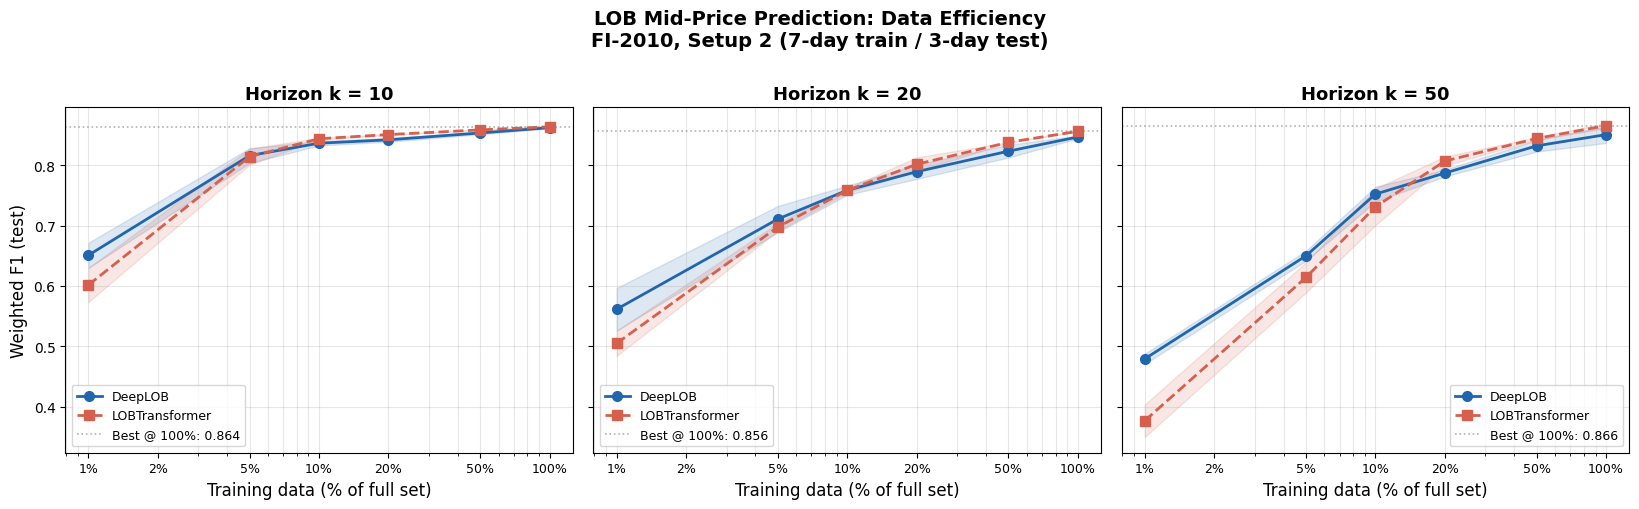

Saved data_efficiency_curves.{pdf,png}


In [ ]:
# ── Figure 1: Data efficiency curves (one subplot per horizon) ───────────────

MODEL_STYLES = {
    'DeepLOB':       {'color': '#2166AC', 'marker': 'o', 'ls': '-'},
    'LOBTransformer': {'color': '#D6604D', 'marker': 's', 'ls': '--'},
}

fig, axes = plt.subplots(1, len(HORIZONS), figsize=(5.5 * len(HORIZONS), 5), sharey=True)
if len(HORIZONS) == 1:
    axes = [axes]

for ax, k in zip(axes, HORIZONS):
    sub = summary[summary['horizon'] == k]

    for model_name, style in MODEL_STYLES.items():
        row = sub[sub['model'] == model_name].sort_values('fraction')
        if row.empty:
            continue
        pct = row['fraction'] * 100
        ax.plot(
            pct, row['f1_mean'],
            label=model_name,
            color=style['color'],
            marker=style['marker'],
            linestyle=style['ls'],
            linewidth=2,
            markersize=7,
        )
        ax.fill_between(
            pct,
            row['f1_mean'] - row['f1_std'],
            row['f1_mean'] + row['f1_std'],
            alpha=0.15, color=style['color']
        )

    # Mark "full data" baseline as reference
    full_rows = sub[sub['fraction'] == 1.0]
    if not full_rows.empty:
        best_full = full_rows['f1_mean'].max()
        ax.axhline(best_full, color='grey', linestyle=':', linewidth=1.2, alpha=0.6,
                   label=f'Best @ 100%: {best_full:.3f}')

    ax.set_xscale('log')
    ax.set_xlabel('Training data (% of full set)', fontsize=12)
    ax.set_title(f'Horizon k = {k}', fontsize=13, fontweight='bold')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.xaxis.set_major_locator(mtick.FixedLocator([1, 2, 5, 10, 20, 50, 100]))
    ax.tick_params(axis='x', labelsize=9)
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=9)

axes[0].set_ylabel('Weighted F1 (test)', fontsize=12)

fig.suptitle(
    'LOB Mid-Price Prediction: Data Efficiency\n'
    'FI-2010, Setup 2 (7-day train / 3-day test)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'data_efficiency_curves.pdf', bbox_inches='tight')
plt.savefig(RESULTS_DIR / 'data_efficiency_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved data_efficiency_curves.{pdf,png}')

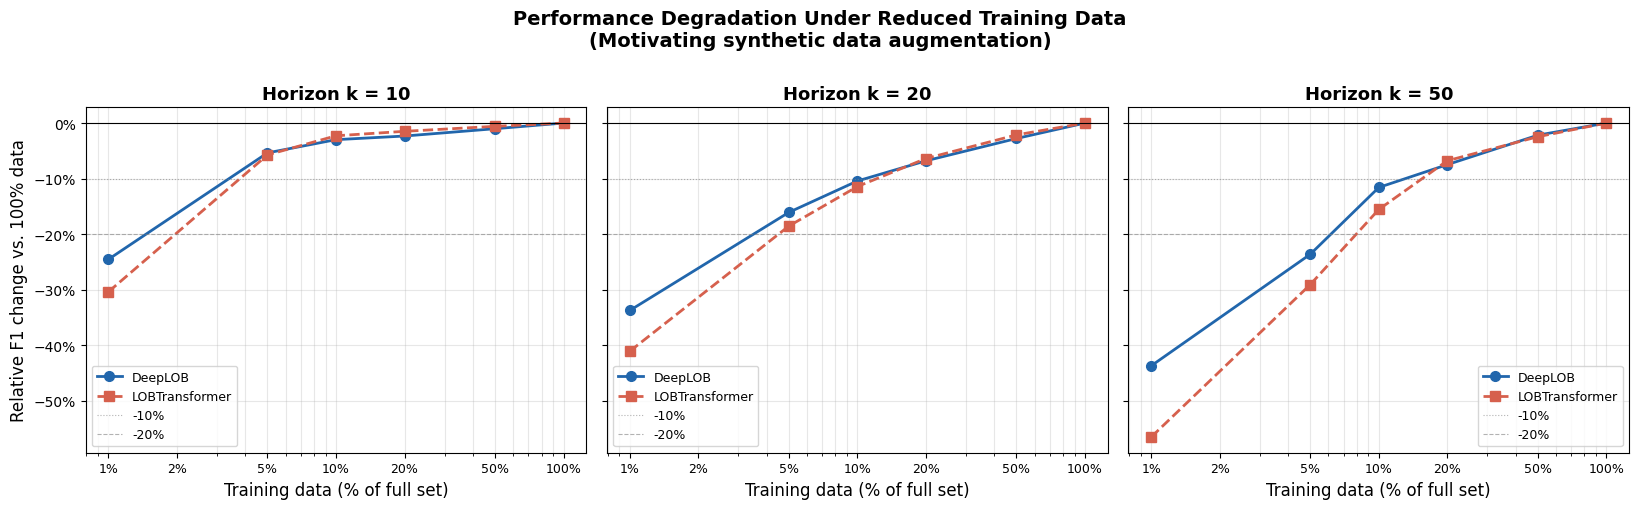

In [ ]:
# ── Figure 2: F1 degradation relative to full-data baseline ────────────────
# Shows relative performance drop as training data is reduced

fig, axes = plt.subplots(1, len(HORIZONS), figsize=(5.5 * len(HORIZONS), 5), sharey=True)
if len(HORIZONS) == 1:
    axes = [axes]

for ax, k in zip(axes, HORIZONS):
    sub = summary[summary['horizon'] == k].copy()

    for model_name, style in MODEL_STYLES.items():
        model_sub = sub[sub['model'] == model_name].sort_values('fraction')
        if model_sub.empty:
            continue
        full_f1 = model_sub[model_sub['fraction'] == 1.0]['f1_mean'].values
        if len(full_f1) == 0:
            continue
        full_f1 = full_f1[0]
        rel_drop = (model_sub['f1_mean'] - full_f1) / full_f1 * 100

        ax.plot(
            model_sub['fraction'] * 100, rel_drop,
            label=model_name,
            color=style['color'],
            marker=style['marker'],
            linestyle=style['ls'],
            linewidth=2, markersize=7,
        )

    ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
    ax.axhline(-10, color='grey', linewidth=0.8, linestyle=':', alpha=0.6, label='-10%')
    ax.axhline(-20, color='grey', linewidth=0.8, linestyle='--', alpha=0.6, label='-20%')

    ax.set_xscale('log')
    ax.set_xlabel('Training data (% of full set)', fontsize=12)
    ax.set_title(f'Horizon k = {k}', fontsize=13, fontweight='bold')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.xaxis.set_major_locator(mtick.FixedLocator([1, 2, 5, 10, 20, 50, 100]))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.tick_params(axis='x', labelsize=9)
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=9)

axes[0].set_ylabel('Relative F1 change vs. 100% data', fontsize=12)

fig.suptitle(
    'Performance Degradation Under Reduced Training Data\n'
    '(Motivating synthetic data augmentation)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'relative_degradation.pdf', bbox_inches='tight')
plt.savefig(RESULTS_DIR / 'relative_degradation.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Table: Fraction at which each model drops below 90% / 80% of full-data F1 ─
print('=== Data sufficiency thresholds ===\n')

thresholds = [0.90, 0.80, 0.70]
rows = []

for k in HORIZONS:
    sub = summary[summary['horizon'] == k]
    for model_name in MODEL_CONFIGS:
        model_sub = sub[sub['model'] == model_name].sort_values('fraction')
        full_f1_rows = model_sub[model_sub['fraction'] == 1.0]
        if full_f1_rows.empty:
            continue
        full_f1 = full_f1_rows['f1_mean'].values[0]
        row_data = {'horizon': k, 'model': model_name, 'full_F1': f'{full_f1:.4f}'}
        for thr in thresholds:
            target = full_f1 * thr
            meeting = model_sub[model_sub['f1_mean'] >= target]['fraction']
            first_meeting = f'{meeting.min() * 100:.0f}%' if not meeting.empty else '>100%'
            row_data[f'≥{thr*100:.0f}% of full F1'] = first_meeting
        rows.append(row_data)

threshold_df = pd.DataFrame(rows)
print(threshold_df.to_string(index=False))
threshold_df.to_csv(RESULTS_DIR / 'sufficiency_thresholds.csv', index=False)

=== Data sufficiency thresholds ===

 horizon          model full_F1 ≥90% of full F1 ≥80% of full F1 ≥70% of full F1
      10        DeepLOB  0.8624              5%              5%              1%
      10 LOBTransformer  0.8638              5%              5%              5%
      20        DeepLOB  0.8469             20%              5%              5%
      20 LOBTransformer  0.8563             20%              5%              5%
      50        DeepLOB  0.8508             20%             10%              5%
      50 LOBTransformer  0.8658             20%             10%              5%


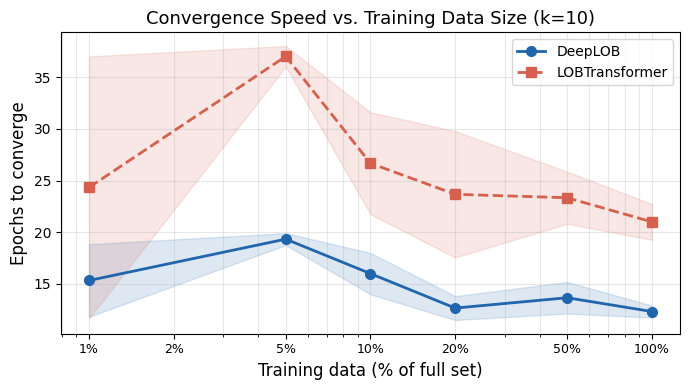

In [ ]:
# ── Figure 3: Epoch convergence speed vs. data fraction (k=10 only) ─────────
# Shows how many epochs are needed to converge as data grows

epoch_data = df[df['horizon'] == HORIZONS[0]].copy()
epoch_summary = (
    epoch_data.groupby(['fraction', 'model'])['n_epochs']
    .agg(['mean', 'std'])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(7, 4))
for model_name, style in MODEL_STYLES.items():
    row = epoch_summary[epoch_summary['model'] == model_name].sort_values('fraction')
    if row.empty:
        continue
    ax.plot(
        row['fraction'] * 100, row['mean'],
        label=model_name,
        color=style['color'], marker=style['marker'],
        linestyle=style['ls'], linewidth=2, markersize=7
    )
    ax.fill_between(
        row['fraction'] * 100,
        row['mean'] - row['std'],
        row['mean'] + row['std'],
        alpha=0.15, color=style['color']
    )

ax.set_xscale('log')
ax.set_xlabel('Training data (% of full set)', fontsize=12)
ax.set_ylabel('Epochs to converge', fontsize=12)
ax.set_title(f'Convergence Speed vs. Training Data Size (k={HORIZONS[0]})', fontsize=13)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.xaxis.set_major_locator(mtick.FixedLocator([1, 2, 5, 10, 20, 50, 100]))
ax.tick_params(axis='x', labelsize=9)
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'convergence_speed.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Training History Deep Dive

Visualise F1 vs. epoch curves for select data fractions to understand *how* each model converges (not just when).

In [ ]:
# ── Re-run a single horizon at select fractions and store histories ──────────
# (Lighter run: k=10, seed=0, fractions [1%, 10%, 100%])

k_demo     = 10
fracs_demo = [0.01, 0.10, 1.00]
histories  = {}  # (model_name, frac) -> history list

X_tr, y_tr, X_te, y_te = fi2010[k_demo]

for frac in fracs_demo:
    set_seed(0)
    train_ld, test_ld, n_tr = make_loaders(
        X_tr, y_tr, X_te, y_te,
        fraction=frac, T=T, batch_size=BATCH_SIZE
    )
    for model_name, cfg in MODEL_CONFIGS.items():
        set_seed(0)
        _, history = train_model(
            cfg['class'], cfg['kwargs'],
            train_ld, test_ld,
            max_epochs=MAX_EPOCHS, patience=PATIENCE,
            verbose=True,
        )
        histories[(model_name, frac)] = history
        print(f'  {model_name} | frac={frac:.0%} | best F1 = {max(h["f1"] for h in history):.4f}')

  Epoch  10 | loss=0.6275 | F1=0.6190
  Early stopping at epoch 12
  DeepLOB | frac=1% | best F1 = 0.6285
  Epoch  10 | loss=0.9219 | F1=0.5382
  Epoch  20 | loss=0.7351 | F1=0.5770
  Early stopping at epoch 29
  LOBTransformer | frac=1% | best F1 = 0.6070
  Epoch  10 | loss=0.4006 | F1=0.8322
  Early stopping at epoch 18
  DeepLOB | frac=10% | best F1 = 0.8333
  Epoch  10 | loss=0.4397 | F1=0.8361
  Epoch  20 | loss=0.3707 | F1=0.8417
  Early stopping at epoch 21
  LOBTransformer | frac=10% | best F1 = 0.8438
  Epoch  10 | loss=0.2803 | F1=0.8563
  Early stopping at epoch 12
  DeepLOB | frac=100% | best F1 = 0.8619
  Epoch  10 | loss=0.3504 | F1=0.8625
  Epoch  20 | loss=0.3067 | F1=0.8637
  Early stopping at epoch 23
  LOBTransformer | frac=100% | best F1 = 0.8646


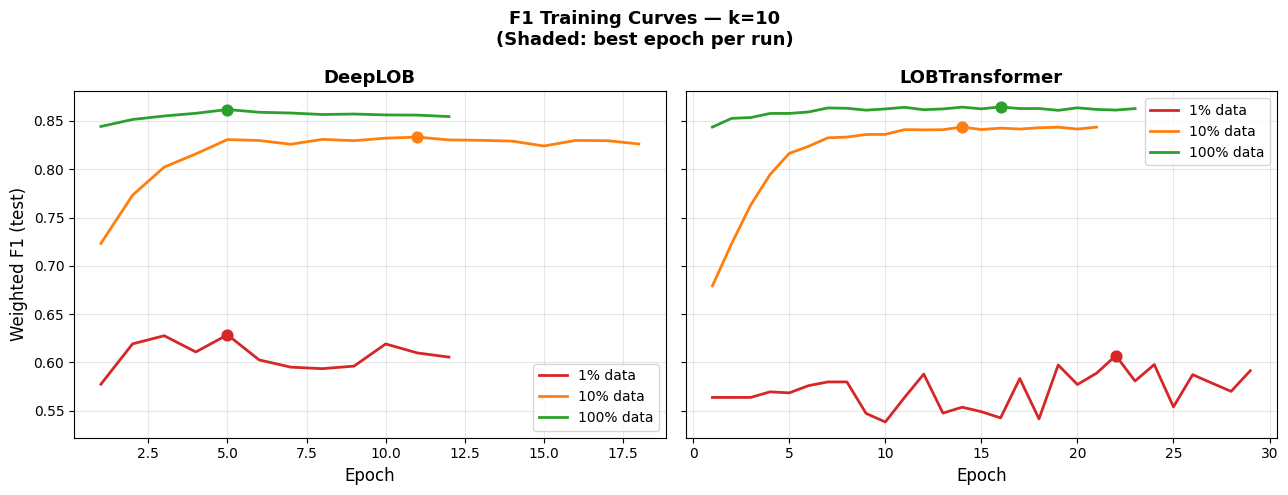

In [ ]:
# ── F1 vs. epoch training curves ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

frac_colors = {0.01: '#d62728', 0.10: '#ff7f0e', 1.00: '#2ca02c'}

for ax, (model_name, _) in zip(axes, MODEL_CONFIGS.items()):
    for frac in fracs_demo:
        hist = histories.get((model_name, frac), [])
        if not hist:
            continue
        epochs = [h['epoch'] for h in hist]
        f1s    = [h['f1']    for h in hist]
        ax.plot(
            epochs, f1s,
            label=f'{frac:.0%} data',
            color=frac_colors[frac], linewidth=2
        )
        # Mark best
        best_idx = np.argmax(f1s)
        ax.scatter(
            epochs[best_idx], f1s[best_idx],
            color=frac_colors[frac], zorder=5, s=60
        )

    ax.set_title(model_name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Weighted F1 (test)', fontsize=12)
fig.suptitle(
    f'F1 Training Curves — k={k_demo}\n'
    '(Shaded: best epoch per run)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary & Implications for Synthetic Data

The cell below prints a structured summary designed to support the argument for synthetic pre-training/augmentation.

In [ ]:
print('=' * 70)
print('SUMMARY: DATA REQUIREMENTS FOR LOB MID-PRICE FORECASTING')
print('=' * 70)

for k in HORIZONS:
    sub = summary[summary['horizon'] == k]
    print(f'\n--- Horizon k={k} ---')
    print(f'  Full training set size (FI-2010 Setup 2): '
          f'{len(LOBDataset(fi2010[k][0], fi2010[k][1], T)):,} samples')

    for model_name in MODEL_CONFIGS:
        model_sub = sub[sub['model'] == model_name].sort_values('fraction')
        full_rows  = model_sub[model_sub['fraction'] == 1.0]
        if full_rows.empty:
            continue
        full_f1  = full_rows['f1_mean'].values[0]

        # Fraction where performance first exceeds 90% of full-data
        target   = full_f1 * 0.90
        meeting  = model_sub[model_sub['f1_mean'] >= target]['fraction']
        min_frac = f'{meeting.min() * 100:.0f}%' if not meeting.empty else 'never'

        print(f'  {model_name:22s} | full-data F1={full_f1:.4f} | '
              f'≥90% at: {min_frac}')

print()
print('Implication:')
print('  If either model requires >10% of real data to reach 90% performance,')
print('  synthetic pre-training (e.g., on LOBS5 or LOBBench) can help fill the gap.')
print('  This is especially critical for low-data regimes (new instruments,')
print('  regime shifts, or proprietary datasets with limited history).')
print('=' * 70)

SUMMARY: DATA REQUIREMENTS FOR LOB MID-PRICE FORECASTING

--- Horizon k=10 ---
  Full training set size (FI-2010 Setup 2): 1,017,639 samples
  DeepLOB                | full-data F1=0.8624 | ≥90% at: 5%
  LOBTransformer         | full-data F1=0.8638 | ≥90% at: 5%

--- Horizon k=20 ---
  Full training set size (FI-2010 Setup 2): 1,017,639 samples
  DeepLOB                | full-data F1=0.8469 | ≥90% at: 20%
  LOBTransformer         | full-data F1=0.8563 | ≥90% at: 20%

--- Horizon k=50 ---
  Full training set size (FI-2010 Setup 2): 1,017,639 samples
  DeepLOB                | full-data F1=0.8508 | ≥90% at: 20%
  LOBTransformer         | full-data F1=0.8658 | ≥90% at: 20%

Implication:
  If either model requires >10% of real data to reach 90% performance,
  synthetic pre-training (e.g., on LOBS5 or LOBBench) can help fill the gap.
  This is especially critical for low-data regimes (new instruments,
  regime shifts, or proprietary datasets with limited history).
